## 8/11 ge calibration

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
header = "data/"
from sklearn.decomposition import PCA

In [12]:

def PCA_fit(Re_c, Im_c):
    pca = PCA()
    data = np.stack([Re_c, Im_c], axis=1)
    pca.fit(data)
    return pca

def PCA_apply(pca, Re_c, Im_c):
    data = np.stack([Re_c, Im_c], axis=1)
    data_centered = data - pca.mean_
    pca_data = data_centered @ pca.components_.T
    return pca_data[:,0], pca_data[:,1]

def Rabi(delay, amp, phi0, detun, const):
    return -amp * np.cos(2*np.pi*detun*delay + phi0) + const

def scale_y(y, ymax, ymin):
    return 2 * (y - ymin) / (ymax - ymin) - 1

def process_Rabi_data(dd, amplitude, par_ini, par_min, par_max, par_vary, pca_model=None, sweep='amplitude'):
    s11 = dd['s11']['values']
    amp = dd[sweep]['values']

    if pca_model is None:
        pca_model = PCA_fit(s11.real, s11.imag)
    PCA1, PCA2 = PCA_apply(pca_model, s11.real, s11.imag)
    
    model = lmfit.Model(Rabi)
    params = model.make_params()
    for name in model.param_names:
        params[name].set(value=par_ini[name], min=par_min[name], max=par_max[name], vary=par_vary[name])
    result = model.fit(data=PCA1, params=params, delay=amp)
    
    # Scaling ±1
    ymax = result.params['amp'].value + result.params['const'].value
    ymin = -result.params['amp'].value + result.params['const'].value
    # plt.plot(PCA1)
    # plt.plot(result.best_fit)
    # plt.show()
    PCA1_scaled = scale_y(PCA1, ymax, ymin)
    fit_scaled = scale_y(result.best_fit, ymax, ymin)
    
    return PCA1_scaled, fit_scaled, pca_model, amp, result


def plot_Rabi_axes(ax, x, y_data, y_fit, color='tab:blue', sign=1):
    ax.plot(x, y_data, "o", c=color)
    # ax.plot(x, y_fit, c="red", lw=1.0)
    x_smooth = np.linspace(np.min(x), np.max(x), 2000)
    y_smooth = y_fit.eval(delay=x_smooth)

    amp = y_fit.params["amp"].value
    const = y_fit.params["const"].value
    ymax = amp + const
    ymin = -amp + const
    y_smooth_scaled = scale_y(y_smooth, ymax, ymin)

    ax.plot(x_smooth, sign*y_smooth_scaled, c="red", lw=1.0)

    ax.tick_params(axis="x", direction="in")
    ax.tick_params(axis="y", direction="in")

ramsey

In [13]:
print(8.207+0.000405764-1.388e-05-1.684e-05+4.0565e-05)
print(8.207+0.000405764-1.388e-05-1.684e-05+4.0565e-05-0.3515-0.00038774-1.309e-05)
print(7.976+0.001277485-2.569e-05)
print(7.976+0.001277485-2.569e-05-0.3558-9.583e-05-4.83e-06-1.066e-05-0.00030885+2.890e-05+3.984e-05)


8.207415609000002
7.855514779000002
7.977251795
7.621100365


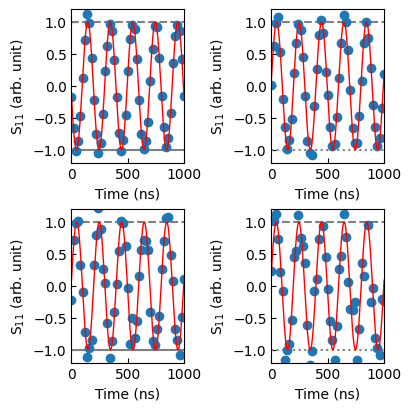

In [15]:
ramsey_ge_tx_path = "/2025-08-11/2025-08-11T141451_1c14a0ee-c3_ge_T2r1d"
dd_ge_tx = datadict_from_hdf5(header + ramsey_ge_tx_path + "/data")
par_ini_tx = {'amp': 0.0003,'phi0':np.pi,'detun':1/200,'const':0.00001}
par_min = {'amp':0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.inf}
par_max = {'amp':np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf}
par_vary = {'amp':True,'phi0':True,'detun':True,'const':True}

PCA1_ge_tx_scaled, fit_ge_tx_scaled, pca_tx, ramsey_ge_tx, res_ge_tx = process_Rabi_data(
    dd_ge_tx, None, par_ini_tx, par_min, par_max, par_vary, sweep="delay"
)

ramsey_ef_tx_path =  "/2025-08-11/2025-08-11T150907_b0a66e72-d2_ef_T2r1d"
dd_ef_tx = datadict_from_hdf5(header + ramsey_ef_tx_path + "/data")
par_ini_tx_ef ={'amp': 0.0001,'phi0':0,'detun':1/200,'const':-0.00004}

PCA1_ef_tx_scaled, fit_ef_tx_scaled, _, ramsey_ef_tx, res_ef_tx = process_Rabi_data(
    dd_ef_tx, None, par_ini_tx_ef, par_min, par_max, par_vary,  sweep="delay"
)


ramsey_ge_rx_path ="/2025-08-11/2025-08-11T221830_ac9df825-c3_ge_T2r1d"
dd_ge_rx = datadict_from_hdf5(header + ramsey_ge_rx_path + "/data")
par_ini_rx ={'amp': 0.0002,'phi0':0,'detun':1/200,'const':0}
PCA1_ge_rx_scaled, fit_ge_rx_scaled, pca_rx, ramsey_ge_rx, res_ge_rx = process_Rabi_data(
    dd_ge_rx, None, par_ini_rx, par_min, par_max, par_vary, sweep="delay"
)

ramsey_ef_rx_path = "/2025-08-11/2025-08-11T230409_0d667cd2-d2_ef_T2r1d"
dd_ef_rx = datadict_from_hdf5(header + ramsey_ef_rx_path + "/data")
par_ini_rx_ef = {'amp': 0.0001,'phi0':0,'detun':1/200,'const':-0.00004}
PCA1_ef_rx_scaled, fit_ef_rx_scaled, _, ramsey_ef_rx, res_ef_rx = process_Rabi_data(
    dd_ef_rx, None, par_ini_rx_ef, par_min, par_max, par_vary, sweep="delay"
)

fig, axes = plt.subplots(2,2, figsize=(4,4), constrained_layout=True)
axes[0,0].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[0,0].axhline(y=-1, color="gray", linewidth=1.5)
axes[0,1].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[0,1].axhline(y=-1, color="gray", linestyle=":", linewidth=1.5)
axes[1,0].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[1,0].axhline(y=-1, color="gray", linewidth=1.5)
axes[1,1].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[1,1].axhline(y=-1, color="gray", linestyle=":", linewidth=1.5)
plot_Rabi_axes(axes[0,0], ramsey_ge_tx, PCA1_ge_tx_scaled, res_ge_tx)
plot_Rabi_axes(axes[0,1], ramsey_ef_tx, PCA1_ef_tx_scaled, res_ef_tx)
plot_Rabi_axes(axes[1,0], ramsey_ge_rx, PCA1_ge_rx_scaled, res_ge_rx)
plot_Rabi_axes(axes[1,1], ramsey_ef_rx, PCA1_ef_rx_scaled, res_ef_rx)

axes[0,0].set_xlabel("Time (ns)")
axes[0,1].set_xlabel("Time (ns)")
axes[1,0].set_xlabel("Time (ns)")
axes[1,1].set_xlabel("Time (ns)")
axes[0,0].set_ylabel("S$_{11}$ (arb. unit)")
axes[1,0].set_ylabel("S$_{11}$ (arb. unit)")
axes[0,1].set_ylabel("S$_{11}$ (arb. unit)")
axes[1,1].set_ylabel("S$_{11}$ (arb. unit)")

axes[0,0].set_xlim(0, 1000); axes[0,1].set_xlim(0,1000)
axes[1,0].set_xlim(0, 1000); axes[1,1].set_xlim(0, 1000)
axes[0,0].set_ylim(-1.2, 1.2); axes[0,1].set_ylim(-1.2, 1.2)
axes[1,0].set_ylim(-1.2, 1.2); axes[1,1].set_ylim(-1.2, 1.2)


plt.show()

T1

In [16]:
def Decay(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

def process_t1_data(dd, amplitude, par_ini, par_min, par_max, par_vary, pca_model=None, sweep='amplitude'):
    s11 = dd['s11']['values']
    delay = dd[sweep]['values']*1e-3
    
    # PCA
    if pca_model is None:
        pca_model = PCA_fit(s11.real, s11.imag)
    PCA1, PCA2 = PCA_apply(pca_model, s11.real, s11.imag)
    
    # Fit
    model = lmfit.Model(Decay)
    params = model.make_params()
    for name in model.param_names:
        params[name].set(value=par_ini[name], min=par_min[name], max=par_max[name], vary=par_vary[name])
    result = model.fit(data=PCA1, params=params, delay=delay)
    
    # Scaling ±1
    ymax = result.params['amp'].value + result.params['const'].value
    ymin = result.params['const'].value
    # plt.plot(PCA1)
    # plt.plot(result.best_fit)
    # plt.show()
    PCA1_scaled = scale_y(PCA1, ymax, ymin)
    fit_scaled = scale_y(result.best_fit, ymax, ymin)
    
    return PCA1_scaled, fit_scaled, pca_model, delay, result

In [28]:
def plot_Rabi_axes(ax, x, y_data, y_fit, color='tab:blue', sign=1):
    ax.plot(x, y_data, "o", c=color)
    ax.plot(x, y_fit, c="red", lw=1.0)

    ax.tick_params(axis="x", direction="in")
    ax.tick_params(axis="y", direction="in")

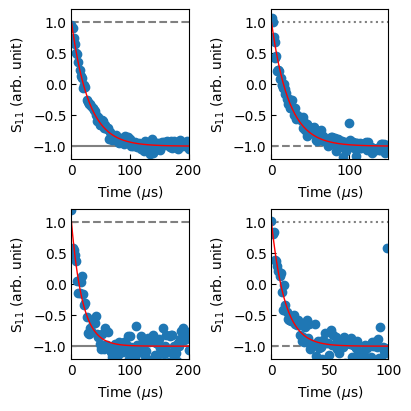

In [19]:
t1_ge_tx_path ="/2025-08-11/2025-08-11T143201_821c7904-c4_ge_T1"
dd_ge_tx = datadict_from_hdf5(header + t1_ge_tx_path + "/data")
par_ini_tx = {'gamma': 1/10000e-3,'amp':1,'const':-2.4}
par_min = {'gamma': -np.inf ,'amp':-np.inf,'const':-np.inf}
par_max = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary = {'gamma': True,'amp':True,'const':True}

PCA1_ge_tx_scaled, fit_ge_tx_scaled, pca_tx, t1_ge_tx, res_ge_tx = process_t1_data(
    dd_ge_tx, None, par_ini_tx, par_min, par_max, par_vary, sweep="delay"
)

t1_ef_tx_path =  "/2025-08-11/2025-08-11T152852_72a69115-d3_ef_T1"
dd_ef_tx = datadict_from_hdf5(header + t1_ef_tx_path + "/data")
# par_ini_tx_ef ={'amp': 0.0001,'phi0':0,'detun':1/200,'const':-0.00004}

PCA1_ef_tx_scaled, fit_ef_tx_scaled, _, t1_ef_tx, res_ef_tx = process_t1_data(
    dd_ef_tx, None, par_ini_tx, par_min, par_max, par_vary,  sweep="delay"
)

t1_ge_rx_path ="/2025-08-11/2025-08-11T223426_e687019f-c4_ge_T1"
dd_ge_rx = datadict_from_hdf5(header + t1_ge_rx_path + "/data")
par_ini_rx = {'gamma': 1/80000e-3,'amp':1,'const':-2.4}
PCA1_ge_rx_scaled, fit_ge_rx_scaled, pca_rx, t1_ge_rx, res_ge_rx = process_t1_data(
    dd_ge_rx, None, par_ini_rx, par_min, par_max, par_vary, sweep="delay"
)

t1_ef_rx_path = "/2025-08-11/2025-08-11T231946_3b826556-d3_ef_T1"
dd_ef_rx = datadict_from_hdf5(header + t1_ef_rx_path + "/data")
# par_ini_rx_ef = {'amp': 0.0001,'phi0':0,'detun':1/200,'const':-0.00004}
PCA1_ef_rx_scaled, fit_ef_rx_scaled, _, t1_ef_rx, res_ef_rx = process_t1_data(
    dd_ef_rx, None, par_ini_rx, par_min, par_max, par_vary, sweep="delay"
)

fig, axes = plt.subplots(2,2, figsize=(4,4), constrained_layout=True)
axes[0,0].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[0,0].axhline(y=-1, color="gray", linewidth=1.5)
axes[0,1].axhline(y=-1, color="gray", linestyle="--", linewidth=1.5)
axes[0,1].axhline(y=1, color="gray", linestyle=":", linewidth=1.5)
axes[1,0].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[1,0].axhline(y=-1, color="gray", linewidth=1.5)
axes[1,1].axhline(y=-1, color="gray", linestyle="--", linewidth=1.5)
axes[1,1].axhline(y=1, color="gray", linestyle=":", linewidth=1.5)

plot_Rabi_axes(axes[0,0], t1_ge_tx, PCA1_ge_tx_scaled, fit_ge_tx_scaled)
plot_Rabi_axes(axes[0,1], t1_ef_tx, PCA1_ef_tx_scaled, fit_ef_tx_scaled)
plot_Rabi_axes(axes[1,0], t1_ge_rx, PCA1_ge_rx_scaled, fit_ge_rx_scaled)
plot_Rabi_axes(axes[1,1], t1_ef_rx, PCA1_ef_rx_scaled, fit_ef_rx_scaled)

axes[0,0].set_xlabel(r"Time ($\mu$s)")
axes[0,1].set_xlabel(r"Time ($\mu$s)")
axes[1,0].set_xlabel(r"Time ($\mu$s)")
axes[1,1].set_xlabel(r"Time ($\mu$s)")
axes[0,0].set_ylabel("S$_{11}$ (arb. unit)")
axes[1,0].set_ylabel("S$_{11}$ (arb. unit)")
axes[0,1].set_ylabel("S$_{11}$ (arb. unit)")
axes[1,1].set_ylabel("S$_{11}$ (arb. unit)")

axes[0,0].set_xlim(0., 200); axes[0,1].set_xlim(0., 150)
axes[1,0].set_xlim(0., 200); axes[1,1].set_xlim(0., 100)
axes[0,0].set_ylim(-1.2, 1.2); axes[0,1].set_ylim(-1.2, 1.2)
axes[1,0].set_ylim(-1.2, 1.2); axes[1,1].set_ylim(-1.2, 1.2)
plt.show()

T2

In [20]:
def T2star(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

def process_t2s_data(dd, amplitude, par_ini, par_min, par_max, par_vary, pca_model=None, sweep='amplitude'):
    s11 = dd['s11']['values']
    delay = dd[sweep]['values']*1e-3
    
    # PCA
    if pca_model is None:
        pca_model = PCA_fit(s11.real, s11.imag)
    PCA1, PCA2 = PCA_apply(pca_model, s11.real, s11.imag)
    
    # Fit
    model = lmfit.Model(T2star)
    params = model.make_params()
    for name in model.param_names:
        params[name].set(value=par_ini[name], min=par_min[name], max=par_max[name], vary=par_vary[name])
    result = model.fit(data=PCA1, params=params, delay=delay)
    
    # Scaling ±1
    ymax = result.params['amp'].value + result.params['const'].value
    ymin = -result.params['amp'].value + result.params['const'].value
    # plt.plot(PCA1)
    # plt.plot(result.best_fit)
    # plt.show()
    PCA1_scaled = scale_y(PCA1, ymax, ymin)
    fit_scaled = scale_y(result.best_fit, ymax, ymin)
    
    return PCA1_scaled, fit_scaled, pca_model, delay, result

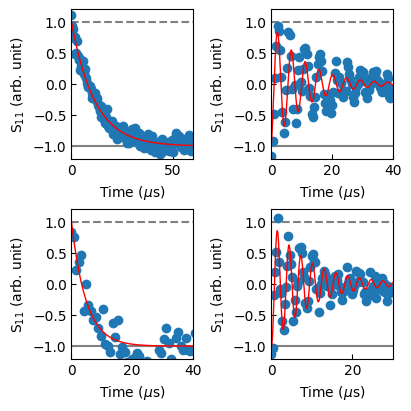

In [29]:
t2e_tx_path ="/2025-08-11/2025-08-11T144137_d8eab06b-c5_ge_T2e"
dd_tx = datadict_from_hdf5(header + t2e_tx_path + "/data")
par_ini_tx = {'gamma': 1/5000e-3,'amp':40,'const':-10}
par_min = {'gamma': -np.inf ,'amp':-np.inf,'const':-np.inf}
par_max = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary = {'gamma': True,'amp':True,'const':True}

PCA1_tx_scaled, fit_tx_scaled, pca_tx, t2e_tx, res_tx = process_t1_data(
    dd_tx, None, par_ini_tx, par_min, par_max, par_vary, sweep="delay"
)

t2e_rx_path ="/2025-08-11/2025-08-11T223709_47d51df2-c5_ge_T2e"
dd_rx = datadict_from_hdf5(header + t2e_rx_path + "/data")
par_ini_rx = {'gamma': 1/5000e-3,'amp':60,'const':-10}
PCA1_rx_scaled, fit_rx_scaled, pca_rx, t2e_rx, res_rx = process_t1_data(
    dd_rx, None, par_ini_rx, par_min, par_max, par_vary, sweep="delay"
)
fig, axes = plt.subplots(2,2, figsize=(4,4), constrained_layout=True)

axes[0,0].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[0,0].axhline(y=-1, color="gray", linewidth=1.5)
axes[0,1].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[0,1].axhline(y=-1, color="gray", linewidth=1.5)
axes[1,0].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[1,0].axhline(y=-1, color="gray", linewidth=1.5)
axes[1,1].axhline(y=1, color="gray", linestyle="--", linewidth=1.5)
axes[1,1].axhline(y=-1, color="gray", linewidth=1.5)

plot_Rabi_axes(axes[0,0], t2e_tx, PCA1_tx_scaled, fit_tx_scaled)
# plot_Rabi_axes(axes[0,1], t2s_tx, -PCA1_tx_scaled_s, -fit_tx_scaled_s)
plot_Rabi_axes(axes[1,0], t2e_rx, PCA1_rx_scaled, fit_rx_scaled)
# plot_Rabi_axes(axes[1,1], t2s_rx, -PCA1_rx_scaled_s, -fit_rx_scaled_s)

def plot_Rabi_axes(ax, x, y_data, y_fit, color='tab:blue', sign=1):
    ax.plot(x, y_data, "o", c=color)
    # ax.plot(x, y_fit, c="red", lw=1.0)
    x_smooth = np.linspace(np.min(x), np.max(x), 2000)
    y_smooth = y_fit.eval(delay=x_smooth)

    amp = y_fit.params["amp"].value
    const = y_fit.params["const"].value
    ymax = amp + const
    ymin = -amp + const
    y_smooth_scaled = scale_y(y_smooth, ymax, ymin)

    ax.plot(x_smooth, sign*y_smooth_scaled, c="red", lw=1.0)

    ax.tick_params(axis="x", direction="in")
    ax.tick_params(axis="y", direction="in")

t2s_tx_path = "/2025-08-11/2025-08-11T143457_eaa588f0-c3_ge_T2r1d"
dd_tx_s = datadict_from_hdf5(header + t2s_tx_path + "/data")
par_ini_tx_s = {'amp':0.0006,'gamma': 1/6000e-3,'omega':2*np.pi/2500e-3,'phi0':0,'const':0}
par_min = {'amp':-np.inf,'gamma': 0,'omega':-2*np.pi,'phi0':-2*np.pi,'const':-np.inf}
par_max = {'amp':np.inf,'gamma': np.inf,'omega':np.inf,'phi0':2*np.pi,'const':np.inf}
par_vary = {'amp':True,'gamma': True,'omega':True,'phi0':True,'const':True}

PCA1_tx_scaled_s, fit_tx_scaled_s, pca_tx_s, t2s_tx, res_tx_s = process_t2s_data(
    dd_tx_s, None, par_ini_tx_s, par_min, par_max, par_vary, sweep="delay"
)

t2s_rx_path ="/2025-08-11/2025-08-11T224128_e21e3e8b-c3_ge_T2r1d"
dd_rx_s = datadict_from_hdf5(header + t2s_rx_path + "/data")
par_ini_rx_s = {'amp':0.0003,'gamma': 1/15000e-3,'omega':2*np.pi/7000e-3,'phi0':0,'const':0}
PCA1_rx_scaled_s, fit_rx_scaled_s, pca_rx_s, t2s_rx, res_rx_s = process_t2s_data(
    dd_rx_s, None, par_ini_rx_s, par_min, par_max, par_vary, sweep="delay"
)



plot_Rabi_axes(axes[0,1], t2s_tx, -PCA1_tx_scaled_s, res_tx_s, sign=-1)
plot_Rabi_axes(axes[1,1], t2s_rx, -PCA1_rx_scaled_s, res_rx_s, sign=-1)

axes[0,0].set_xlabel(r"Time ($\mu$s)")
axes[0,1].set_xlabel(r"Time ($\mu$s)")
axes[1,0].set_xlabel(r"Time ($\mu$s)")
axes[1,1].set_xlabel(r"Time ($\mu$s)")
axes[0,0].set_ylabel("S$_{11}$ (arb. unit)")
axes[1,0].set_ylabel("S$_{11}$ (arb. unit)")
axes[0,1].set_ylabel("S$_{11}$ (arb. unit)")
axes[1,1].set_ylabel("S$_{11}$ (arb. unit)")

axes[0,0].set_xlim(0., 60); axes[0,1].set_xlim(0., 40)
axes[1,0].set_xlim(0., 40); axes[1,1].set_xlim(0., 30)
axes[0,0].set_ylim(-1.2, 1.2); axes[0,1].set_ylim(-1.2, 1.2)
axes[1,0].set_ylim(-1.2, 1.2); axes[1,1].set_ylim(-1.2, 1.2)
plt.show()